In [1]:
import numpy as np
from numba import njit
import matplotlib.pyplot as plt
import pathlib,sys,os,json
from cupy.fft import rfft2,irfft2
import cupy.fft as fft
from matplotlib.colors import TwoSlopeNorm
import matplotlib as mpl
mpl.rc("text", usetex = True)
import h5py,math
import cupy as cp
from scipy.interpolate import splrep, splev, splder,sproot,PPoly


In [3]:
## ---------------- params ----------------------- ## 
paramfile = 'parameters.json'
with open(paramfile,'r') as jsonFile: params = json.load(jsonFile)
PI = np.pi
TWO_PI = 2*PI
d = params["d"] # Dimension
nu =params["nu"] # Viscosity
Re = 1/nu if nu > 0 else np.inf # Reynolds number
N = Nx = Ny = params["N"] # Grid size
dt = params["dt"] # Timestep
# T = params["T"] # Final time
T = 110# Final time
einit = params["einit"] # Initial energy
kinit = params["kinit"] # Initial energy is distributed among these wavenumbers
linnu = params["linnu"] # Linear drag co-efficient
lp = params["lp"] # Power of the laplacian in the hyperviscous term
shell_count = params["shell_count"] # The shells where the energy is injected
alph = params["alph"] # The density ratio
Nprtcl = int(params["Nprtcl"]*Nx*Ny) # Number of particles
tf = params["tf"] # Final time for the particles
st = params["st"]*tf # Time period for the particles
tp = st # Save the particle data after this many timesteps
savestep = int(params["savestep"]/dt) # Save the data after this many timesteps
prtcl_savestep = int(params["prtcl_savestep"]/dt) # Save the particle data after this many timesteps
eta = params["eta"]/(Nx//3) # Desired Kolmogorov length scale
restart = params["restart"] # Restart from the last saved data
kf = params["kf"] # Forcing wavenumber
f0 = params["f0"] # Forcing amplitude
order = params["order"] # Order of the spline interpolation
# t = np.arange(0,1.1*dt + T,dt) # Time array
P = (nu**3/eta**4)/len(shell_count) # power per unit shell
print(f"Number of particles: {Nprtcl}, stokes number in simulation time {st}")
## ----------------------------------------------- ##


Number of particles: 314572, stokes number in simulation time 0.8999999999999999


In [4]:

print(f"alpha {alph}")

## ---------- Grid and wavenumbers --------------- ##
Lx, Ly = (2*np.pi),(2*np.pi) #Length of the grid
X,Y = np.linspace(0,Lx,Nx,endpoint= False), np.linspace(0,Ly,Ny,endpoint= False)
dx = X[1] - X[0]
dy = Y[1] - Y[0]
x,y = np.meshgrid(X,Y,indexing="ij")
PI = np.pi
TWO_PI = 2*PI

## It is best to define the function which returns the real part of the iifted function as ifft. 
ifft2 = lambda x,axis = None: irfft2(x,(Nx,Ny),axes = axis)

## Forming the 2D grid (k space)
Kx = 2*np.pi*np.linspace(-(Nx//2) , Nx//2 - 0.5*(1+ (-1)**(Nx%2)),Nx)/Lx
Ky = 2*np.pi*np.linspace(-(Ny//2) , Ny//2 - 0.5*(1+ (-1)**(Ny%2)),Ny)/Ly
Kx = np.append(Kx[Kx>=0], Kx[Kx<0])
Ky = np.append(Ky[Ky>=0], -Ky[0])
kx,ky = np.meshgrid(Kx,Ky,indexing="ij")
## Defining the inverese laplacian.
lap = -(kx**2 + ky**2)
# lap1 = lap.copy()
# lap1[lap1== 0] = np.inf
lapinv = 1.0/np.where(lap == 0., np.inf, lap)
kx.shape
## ----------------------------------------------- ##


alpha 0.7


(1024, 513)

In [5]:
def find_range(x,idx): return np.sum(np.cumsum(x[:idx][::-1]) == range(1,len(x[:idx])+1))+np.sum(np.cumsum(x[idx:])== range(1,len(x[idx:])+1))


In [6]:

 
idx = cp.zeros((Nprtcl,d),dtype = int)
slx = idx[:,0].copy()
sly = idx[:,1].copy()
delx = cp.zeros((Nprtcl,d),dtype = cp.float64)
temparr = cp.zeros((Nprtcl),dtype=cp.float64)
poly = cp.zeros((Nprtcl,d,order),dtype = cp.float64)
Lx = Ly = TWO_PI
X,Y = np.linspace(0,Lx,Nx,endpoint= False), np.linspace(0,Ly,Ny,endpoint= False)
dx = X[1] - X[0]
dy = Y[1] - Y[0]


In [20]:

def initialize_b_spline(order,X,dx,Nx):
    """
    Initializes the Matrix M and coefficient array ck in 2D according to hinsberg et al.
    ck is not computed using the formula. Rather doing 1/F(b_d) where F is the fourier transform of the b_d function given in (7.6).
    Mmat is compute using (7.4)
    """
    Mmat = cp.zeros((order,order))
    for i in range(order):
        for j in range(order):
            for s in range(j,order):
                Mmat[j,i] += (-1)**(s-j)*math.factorial(order)*(order - s-1)**(order-i-1)/(math.factorial(s-j)*math.factorial(order +j -s))
            
        Mmat[:,i] = Mmat[:,i]/(math.factorial(order-i-1)*math.factorial(i))
    Mmat = cp.array(Mmat)

    def bj(x,j): 
        bj = 0
        for i in range(order):
            bj += Mmat[j,i]*(x -order/2 + j+1)**(i)
        return bj*((x -order/2 + j+1) < 1)*(x -order/2 + j+1 >= 0)

    bm = 0. 
    xeval = cp.array(X/dx*((X//dx<Nx/2)) + (X/dx - Nx)*(X//dx>=Nx/2))
    for j in range(order):
        bm += bj(xeval,j)


    bk = fft.fft(bm)
    ck = 1./bk
    ckxky = ck[:,None]*ck[None,:]
    cxy = fft.ifft2(ckxky).real
    ck2d = fft.rfft2(cxy) #! This will be multiplied with all the fields to be interpolated. 
    
    del bm,bk,ck,ckxky,cxy
    nums = cp.arange(order)
    
    return ck2d,Mmat,nums
ck2d, Mmat, nums = initialize_b_spline(order,X,dx,Nx)   


In [21]:

def interp_spline(pos,u_field):
    """
    b-spline interpolation of the specified order given in Hinsberg et al.
    """
    global nums,idx,delx,poly,slx,sly,temparr,order,Mmat,dx,N,Nprtcl
    
    umat = 0.0
    pos_gpu = cp.array(pos)
    idx[:] = (pos_gpu//dx).astype(cp.int32)
    delx[:] = (pos_gpu%dx)/dx    
    poly[:] = delx[...,None]**nums
        
    #! This is the main loop for the interpolation. The loop is replaced by kernel code which makes it faster. 
    for i in range(order):
        for j in range(order):
            temparr[:] = np.einsum('p,q,...p,...q->...',Mmat[i],Mmat[j],poly[...,0,:],poly[...,1,:]) #! For saving computations
            slx[:] = (idx[:,0]-order/2 + 1 + i)%N #! For saving computations
            sly[:] = (idx[:,1]-order/2 + 1 + j)%N #! For saving computations
            
            umat  += cp.array(u_field)[slx,sly,...]*temparr[:]            
            
    return umat.get()



In [22]:

curr_path = pathlib.Path("/home/rajarshi.chattopadhyay/fluid/2DV_and_particles/postproc_new_new.py").parent 
iname = "bspline" if order >1 else "linear"
savePlot = pathlib.Path(f"/home/rajarshi.chattopadhyay/fluid/2DV_and_particles/Plots/{iname}/Re_{np.round(Re,2)},dt_{dt},N_{N}/")
savePlot.mkdir(parents=True, exist_ok=True)
loadPath = pathlib.Path(f"data_{iname}/Re_{np.round(Re,2)},dt_{dt},N_{Nx}/")
prtcl_loadPath = loadPath/f"alpha_{alph:.2}_prtcl/St_{st/tf:.2f}/"
loadPath.exists()
# loadPath = pathlib.Path(f"/mnt/pfs/rajarshi.chattopadhyay/Caustics3D/data_new/fluid/omg/alph_0.7000/st_0.00848/dt_8.48e-06")
try: savePlot.mkdir(parents=True, exist_ok=False)
except FileExistsError: pass
savePlotdataPath = savePlot.parent/f"plotdat"
try: savePlotdataPath.mkdir(parents = True, exist_ok = False)
except FileExistsError: pass

len(os.listdir(loadPath)), alph

(4341, 0.8)

In [23]:

times = np.arange(0,T+ 0.1,params["savestep"])

#! Goal -- load files one by one, extract caustics and non-caustics particles.
"""Check and store statistics. And be done with it
Stats to store: 
The eigenvaules series for caustics particles.
The time of caustics

"""

print(times[-1],st,str(savePlot))
Ntimes = len(times)
TrZ = np.zeros((Ntimes, Nprtcl))
TrZ2 = np.zeros((Ntimes,Nprtcl))
Z = np.zeros((Nprtcl,d,d))
caus_count = np.zeros((Ntimes, Nprtcl))
vel = np.zeros((Ntimes, Nprtcl,d))
pos = np.zeros((Ntimes, Nprtcl,d))
Qmean = np.zeros((Ntimes))
Qstd = np.zeros((Ntimes))
Qinterp = np.zeros((Ntimes, Nprtcl))
siginterp = np.zeros((Ntimes, Nprtcl))
xiinterp = np.zeros((Ntimes, Nprtcl))
causQmean = np.zeros(Ntimes)
causQstd = np.zeros(Ntimes)
Qmax = 0.5
Qmin = -0.5
Qbins = np.linspace(Qmin,Qmax, 6001)
Q_field_pdf = np.zeros((Ntimes,len(Qbins)-1))
Q_particle_pdf = np.zeros((Ntimes,len(Qbins)-1))
Q_caus_pdf = np.zeros((Ntimes,len(Qbins)-1))
xi = np.zeros((Nx,Ny//2+1),dtype = np.complex128)
A = np.zeros((d,d,Nx,Ny//2+1),dtype = np.complex128)
u = xi.copy()
v = xi.copy()
xi_r = np.zeros((Nx,Ny),dtype = np.float64)
Q_field = xi_r.copy()
sig_field = xi_r.copy()
Ar = np.zeros((d,d,Nx,Ny),dtype = np.float64)
# eiga = np.zeros((Ntimes, Nprtcl,3)).astype(complex)
# eigz = np.zeros((Ntimes, Nprtcl,3)).astype(complex)
# causeiga = []
# causeigz = [] 
# causTrZ = []
# causvel = []
# causno = 0
# Q_llim = -0.3
# Q_ulim = 0.6
# R_llim = -0.03
# R_ulim = 0.03
# tbins = np.linspace(times[0],times[-1],2001)
# Qbins = np.linspace(Q_llim,Q_ulim, 201)
# Rbins = np.linspace(R_llim,R_ulim, 201)
# Qpdf = np.zeros((len(tbins) -1,len(Qbins) -1))
# Rpdf = np.zeros((len(tbins) -1,len(Rbins) -1))
# initQ = np.zeros((Nprtcl))
# initR = np.zeros((Nprtcl))
tip = np.zeros(Nprtcl)
tfp = np.zeros(Nprtcl)
tis = np.array([])
tfs = np.array([])
prtcls = np.array([])
xi = np.zeros((Nx,Ny//2+1),dtype = np.complex128)
xi_r = np.zeros((Nx,Ny),dtype = np.float64)
u = np.zeros((Nx,Ny//2+1),dtype = np.complex128)
v = np.zeros((Nx,Ny//2+1),dtype = np.complex128)
Q_field = np.zeros((Nx,Ny),dtype = np.float64)


110.0 0.8999999999999999 /home/rajarshi.chattopadhyay/fluid/2DV_and_particles/Plots/bspline/Re_125000.0,dt_0.005,N_1024


In [24]:

for i,t in enumerate(times):
    print(f"loading time {t}",end='\r')
    Z[:] =  np.load(prtcl_loadPath/f"time_{t:.2f}/prtcl_Z.npz")["Zmatrix"]
    # Z[:] =  np.load(prtcl_loadPath/f"time_{t:.2f}/prtcl_Z.npy")
    TrZ[i] = np.einsum('...ii->...', Z)
    TrZ2[i] = np.einsum('...ij,...ji->...', Z,Z)
    caus_count[i] =  np.load(prtcl_loadPath/f"time_{t:.2f}/caus_count.npz")["caustics_count"]
    # caus_count[i] =  np.load(prtcl_loadPath/f"time_{t:.2f}/caus_count.npy")
    final_caus_count = np.load(prtcl_loadPath/f"time_{times[-1]:.2f}/caus_count.npz")["caustics_count"]
    # final_caus_count = np.load(prtcl_loadPath/f"time_{times[-1]:.2f}/caus_count.npy")
    # print(f"final_caus_count: {np.sum(final_caus_count>0)}")
    newcaus_idx = np.argwhere(caus_count[i] > caus_count[i-1]) if i>0 else np.array([])
    if newcaus_idx.size>0:
        # print(newcaus_idx.size)
        tfp[newcaus_idx] = t
        tis = np.append(tis,tip[newcaus_idx])
        tfs = np.append(tfs,tfp[newcaus_idx])
        prtcls = np.append(prtcls,newcaus_idx)
        tip[newcaus_idx] = t


    # vel[i] = np.load(prtcl_loadPath/f"time_{t:.2f}/vel.npy") 
    vel[i] = np.load(prtcl_loadPath/f"time_{t:.2f}/vel.npz")["vel"]
    # pos[i] = np.load(prtcl_loadPath/f"time_{t:.2f}/pos.npy")
    pos[i] = np.load(prtcl_loadPath/f"time_{t:.2f}/pos.npz")["pos"]
    
    xi[:] = np.load(loadPath/f"time_{t:.2f}/w.npz")["vorticity"]
    xi_r[:] = ifft2(cp.array(xi)).get()
    # print(xi_r.max(),np.sqrt(np.mean(xi_r**2)))
    u[:] = 1j* ky*lapinv*xi
    v[:] = -1j*kx*lapinv*xi
    # ur = ifft2(u) 
    # vr = ifft2(v)
    A[0,0] = 1j*kx*u
    A[0,1] = 1j*ky*u
    A[1,0] = 1j*kx*v
    A[1,1] = 1j*ky*v
    Q_field[:] = 0.0
    Ar[:] = ifft2(cp.array(A),axis = (2,3)).get()
    # for ii in range(d):
    #     for jj in range(d):
    #         Ar[ii,jj] = ifft2(cp.array(A[ii,jj])).get()

    Q_field[:] = -0.5*np.einsum('ij...,ji...->...',Ar,Ar)
    sig_field[:] = (xi_r**2 - 4*Q_field)**0.5
    Q_field_pdf[i,:]  = np.histogram(st**2*Q_field.ravel(),bins = Qbins)[0]/(Nx*Ny)
    if i == 0:
        xi_rms = st*np.sqrt(np.mean(st*xi_r**2))
        sig_rms = st*np.sqrt(np.mean(sig_field**2))
        Q_rms = st**2*np.sqrt(np.mean(Q_field**2))
    
    # print(Q_field.shape)
    # print(np.max(Q_field),np.min(Q_field),np.mean(Q_field))
    # pos_test = np.array([(x.ravel())[::2],(y.ravel())[::2]]).T + np.random.random((Nx*Ny//2,2))*dx*0.1
    # Qinterp_test = np.zeros(pos_test.shape[0])
    # Qinterp_test[:] = interp_spline(pos_test,Q_field,Qinterp_test)
    # print(np.min(Qinterp_test),np.mean(Qinterp_test),np.max(Qinterp_test))
    Qinterp[i,:] = st**2*interp_spline(pos[i],Q_field) 
    xiinterp[i,:] = st*interp_spline(pos[i],xi_r)
    
    Q_particle_pdf[i,:] = np.histogram(Qinterp[i,:],bins = Qbins)[0]/Nprtcl
    #print(np.min(Qinterp[i,:]),np.mean(Qinterp[i,:]),np.max(Qinterp[i,:]))
    #print(i)
    causidx = np.argwhere(caus_count[i] > 0)

    if caus_count[i].any() > 0:
        causQmean[i] = np.mean(Qinterp[i,causidx])
        causQstd[i] = np.std(Qinterp[i,causidx])
        Q_caus_pdf[i,:] = np.histogram(Qinterp[i,causidx],bins = Qbins)[0]/np.sum(caus_count[i] > 0)
    # Omean[i] = np.mean(Qinterp)
    # Qstd[i] = np.std(Qinterp)
# print(Qinterp)
# Q_caus = Qinterp[:,caus_count[-1] > 0]


In [25]:
causidx = np.argwhere(caus_count[-1] > 0)
noncausidx = np.argwhere(caus_count[-1] == 0)
caus_count[-1].sum(), (caus_count[-1] > 0).sum()


(7247.0, 7177)

In [11]:

del pos,vel


In [26]:

# %%
maxdt = np.max(tfs-tis)
maxsize = np.sum(times<= maxdt) + 1
Q_caus_shifted = np.ones((maxsize,int(np.sum(caus_count[-1]))))*np.nan
omg_caus_shifted = np.ones((maxsize,int(np.sum(caus_count[-1]))))*np.nan
TrZ_shifted = np.ones((maxsize,int(np.sum(caus_count[-1]))))*np.nan
TrZ2_shifted = np.ones((maxsize,int(np.sum(caus_count[-1]))))*np.nan
t_caus_len = np.zeros(int(np.sum(caus_count[-1])))
Q_initial = np.zeros(int(np.sum(caus_count[-1])))
omg_initial = np.zeros(int(np.sum(caus_count[-1])))
t_mins = np.zeros(int(np.sum(caus_count[-1])))
Q_mins = np.zeros(int(np.sum(caus_count[-1])))
                    

In [ ]:

if (prtcl_loadPath/f"caus-details.hdf5").exists():
    os.remove(prtcl_loadPath/f"caus-details.hdf5")

with h5py.File(prtcl_loadPath/f"caus-details.hdf5",'w') as f:
    # try:
    caus_ratio = f.create_dataset("Caustics_ratio",data = (np.sum(caus_count>0,axis = 1)/Nprtcl),dtype = np.float64)
    times = f.create_dataset("times",data = times,dtype = np.float64)
    caus_new = np.sum(caus_count>0,axis = 1)/Nprtcl -np.roll(np.sum(caus_count>0,axis = 1)/Nprtcl ,1)
    caus_new[0] = 0
    newcaus = f.create_dataset("new_caus",data =  caus_new,dtype = np.float64)
    caus_same = np.sum((caus_count >1)*(caus_count > np.roll(caus_count,1,axis = 0)),axis = 1)/Nprtcl
    caus_same[0] = 0
    samecaus = f.create_dataset("same_caus",data = caus_same,dtype = np.float64)
    
    meanQ = np.mean(Qinterp,axis = 1)
    print(meanQ)
    stdQ = np.std(Qinterp,axis = 1)
    print(np.min(stdQ),np.max(stdQ))
    Qmean = f.create_dataset("Qmean",data = meanQ,dtype = np.float64)
    Qstd = f.create_dataset("Qstd",data = stdQ,dtype = np.float64)

    causQmean = f.create_dataset("causQmean",data = causQmean,dtype = np.float64)
    causQstd = f.create_dataset("causQstd",data = causQstd,dtype = np.float64)
    
    Q_field_pdf = f.create_dataset("Q_field_pdf",data = Q_field_pdf,dtype = np.float64)
    Q_particle_pdf = f.create_dataset("Q_particle_pdf",data = Q_particle_pdf,dtype = np.float64)
    Q_caus_pdf = f.create_dataset("Q_caus_pdf",data = Q_caus_pdf,dtype = np.float64)

del caus_ratio,caus_new, caus_same,causQmean,causQstd,Qmean,Qstd,Q_field_pdf,Q_particle_pdf,Q_caus_pdf
del causQmean,causQstd,Qmean,Qstd,Q_field_pdf,Q_particle_pdf,Q_caus_pdf


In [27]:
causidx = np.argwhere(caus_count[-1] > 0)

np.sum(caus_count[-1])

7247.0

# <center> Making calculating the mean before caustics

1. Make bspline interp
2. Calculate derivative of the spline function. 
3. Find the time for the last zero
4. Find the times there and the Q from there. 

In [28]:
def compute_extrema(x,y,count_number):
    """Outputs the value of x for which the derivative of y is zero 
    With a syntax copied from Microsoft Copilot.
    """
    tck = splrep(x,y,k = 5)
    tck_der = splder(tck)
    # print(PPoly.from_spline(tck_der).roots(extrapolate = False))
    try: last_root = PPoly.from_spline(tck_der).roots(extrapolate = False)[-1]
    except :
        idx = -1 if y[-1] < y[0] else 0
        count_number += 1
        return x[idx],y[idx],count_number
    return x[x>last_root][0],y[x>last_root][0],count_number

In [30]:
xtest = np.linspace(0,2*np.pi,50)
ytest = np.sin(xtest*4)

xroot,yroot,count_number  = compute_extrema(xtest,ytest,0)
print(xroot)

5.898500492454305


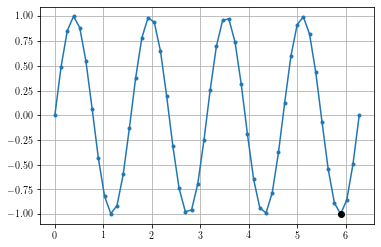

In [32]:
plt.plot(xtest,ytest,'.-')
# plt.plot(xtest,4*np.cos(xtest*4),color = 'red')
plt.plot(xroot,yroot,'o',color = 'black')
plt.grid()

In [34]:
ins = 0
meant_min = 0.0
meanQ_min = 0.0
count_number = 0
for i in causidx.ravel():
    # print(i)
    # print(caus_count[-1,i])
    """
    For each particle, cau_count will give how many instances to split the particle into. 
    Then for each of the instances, add the Q in the Q_caus_pdf. 
    """
    # print(caus_count[-1,i])
    caus_count[:,i]
    
    for j in range(int(caus_count[-1,i])):
        region = ((caus_count[:,i] > j-1)*(caus_count[:,i] <= j)).ravel() #region in time where this caustics happened
        regionlen = np.sum(region)
        try:
            t_caus_len[ins] = regionlen
            Q_caus_shifted[(maxsize-regionlen):,ins] = Qinterp[region,i] # Adding the trajectory of the particle and rest zero.
            t_caus_local = times[:regionlen]
            t_caus_local = t_caus_local - t_caus_local[-1]
            t_mins[ins],Q_mins[ins],count_number = compute_extrema(t_caus_local,Qinterp[region,i],count_number)
            Q_initial[ins] = Q_caus_shifted[(maxsize-regionlen),ins]
            omg_caus_shifted[(maxsize-regionlen):,ins] = xiinterp[region,i]
            omg_initial[ins] = omg_caus_shifted[(maxsize-regionlen),ins]
            TrZ_shifted[(maxsize-regionlen):,ins] = TrZ[region,i]
            TrZ2_shifted[(maxsize-regionlen):,ins] = TrZ2[region,i]
        except:
            print((maxsize-regionlen), regionlen,ins, Q_caus_shifted.shape)
            raise SystemExit

        ins = ins + 1
        
meant_min = np.mean(t_mins)
meanQ_min = np.mean(Q_mins)
meant_min, meanQ_min,count_number

(-4.470801711052849, -0.12015223841903648, 0)

In [ ]:
sig_caus_shifted = (omg_caus_shifted**2 - 4*Q_caus_shifted)**0.5
sig_caus_shifted.imag.max()

In [36]:
meant_min, meanQ_min,count_number

(-4.470801711052849, -0.12015223841903648, 0)

In [37]:
meanQ_min_wrong = np.mean(np.nanmin(Q_caus_shifted,axis = 0))
minQ_mean = np.nanmin(np.nanmean(Q_caus_shifted,axis = 1))


/tmp/ipykernel_8583/2313038825.py:2: RuntimeWarning: Mean of empty slice
  minQ_mean = np.nanmin(np.nanmean(Q_caus_shifted,axis = 1))


(-0.11034680671842946, -0.13770128591754935, -0.12015223841903648)

In [38]:
ins,np.sum(caus_count[-1])

(7247, 7247.0)

# <center> Trajectories of non-caustics particles

1. Find the minima of Q for caustics particles. 
2. Check the particles that pass between the standard deviation of the trajectory. 
3. Find store the average trajectory 20*tp before and after entering the trajectory. 


In [91]:
stdQ_min = np.std(Q_mins)
minQ = meanQ_min + stdQ_min

noncausticsidx = np.argwhere(caus_count[-1] == 0).ravel()
minQ,meanQ_min

(-0.06960537528340799, -0.12015223841903648)

In [126]:
Qinterp_nc = Qinterp[:,noncausticsidx] 
satisfying_conditionidx = (Qinterp_nc < minQ).any(axis = 0)

Qinterp_nc = Qinterp_nc[0:,satisfying_conditionidx][:,np.random.choice(satisfying_conditionidx.sum(),max(ins,50000))]


In [ ]:
del Qinterp,xiinterp
print(ins)

In [ ]:
sig_initial = np.sqrt(omg_initial**2 - 4*Q_initial)**0.5
Q_caus_shifted_vort = Q_caus_shifted[:,Q_initial>0]
Q_caus_shifted_strain = Q_caus_shifted[:,Q_initial<0]
Q_caus_shifted_extreme_vort = Q_caus_shifted[:,np.abs(omg_initial)>2*xi_rms]
Q_caus_shifted_extreme_strain = Q_caus_shifted[:,sig_initial>2*sig_rms]
Q_caus_shifted_extreme_pos_Q = Q_caus_shifted[:,Q_initial>4*Q_rms]
Q_caus_shifted_extreme_neg_Q = Q_caus_shifted[:,Q_initial<-4*Q_rms]

In [128]:
Q_nc_shifted = np.zeros_like(Qinterp_nc)*np.nan
for i in range(Qinterp_nc.shape[1]):
    tidx  = np.argwhere(Qinterp_nc[:,i] < minQ).ravel()[0]
    if tidx > len(times)//2: 
        Q_nc_shifted[len(times)//2:3*len(times)//2 -tidx ,i] = Qinterp_nc[tidx:,i]
        Q_nc_shifted[:len(times)//2,i] = Qinterp_nc[tidx- len(times)//2:tidx,i]
    else:
        Q_nc_shifted[len(times)//2+1:,i] = Qinterp_nc[tidx:tidx+len(times)//2,i]
        Q_nc_shifted[len(times)//2 - tidx:len(times)//2,i] = Qinterp_nc[:tidx,i]
        
        
    

In [129]:
mean_nc = np.nanmean(Q_nc_shifted,axis = 1)

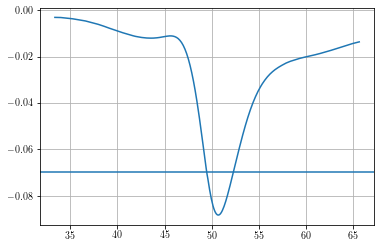

In [130]:
times_plot = (times > times[-1]//2 - 20*tp) * (times < times[-1]//2 + 20*tp)
plt.plot(times[times_plot]*tp,mean_nc[times_plot])
plt.axhline(minQ)
plt.grid()

In [ ]:

    
# print(f"fraction of caustics: {np.sum(caus_count,axis = 1)/Nprtcl} at stokes number {st/tf}")
def first_value(x):
    """This returns the first non-zero value of the shifted Q_caus"""
    
    diff_gate = np.cumsum((x !=0)*1,axis = 0)
    return x[diff_gate == 1]
    



In [ ]:

print(Q_caus_shifted_strain.shape,Q_caus_shifted_vort.shape,Q_caus_shifted_extreme_vort.shape, Q_caus_shifted_extreme_strain.shape, Q_caus_shifted_extreme_pos_Q.shape,Q_caus_shifted_extreme_neg_Q.shape
)
with h5py.File(prtcl_loadPath/f"caus-details.hdf5",'a') as f:
    
    Q_caus_shifted = f.create_dataset("Q_caus_shifted",data = Q_caus_shifted,dtype = np.float64,compression = 'gzip')
    print(f"Saved the data in {str(prtcl_loadPath)}")
    omg_caus_shifted = f.create_dataset("omg_caus_shifted",data = omg_caus_shifted,dtype = np.float64,compression = 'gzip')
    TrZ_shifted = f.create_dataset("TrZ_shifted",data = TrZ_shifted,dtype = np.float64,compression = 'gzip')
    TrZ2_shifted = f.create_dataset("TrZ2_shifted",data = TrZ2_shifted,dtype = np.float64,compression = 'gzip')
    Q_caus_shifted_vort = f.create_dataset("Q_caus_shifted_vort",data = Q_caus_shifted_vort,dtype = np.float64,compression = 'gzip')
    Q_caus_shifted_strain = f.create_dataset("Q_caus_shifted_strain",data = Q_caus_shifted_strain,dtype = np.float64,compression = 'gzip')
    Q_caus_shifted_extreme_vort = f.create_dataset("Q_caus_shifted_extreme_vort",data = Q_caus_shifted_extreme_vort,dtype = np.float64,compression = 'gzip')
    Q_caus_shifted_extreme_strain = f.create_dataset("Q_caus_shifted_extreme_strain",data = Q_caus_shifted_extreme_strain,dtype = np.float64,compression = 'gzip')
    Q_caus_shifted_extreme_pos_Q = f.create_dataset("Q_caus_shifted_extreme_pos_Q",data = Q_caus_shifted_extreme_pos_Q,dtype = np.float64,compression = 'gzip')
    Q_caus_shifted_extreme_neg_Q = f.create_dataset("Q_caus_shifted_extreme_neg_Q",data = Q_caus_shifted_extreme_neg_Q,dtype = np.float64,compression = 'gzip')
    t_caus_len = f.create_dataset("t_caus_len",data = t_caus_len,dtype = np.float64,compression = 'gzip')
    Q_nc_shifted = f.create_dataset("Q_nc_shifted",data = Q_nc_shifted,dtype = np.float64,compression = 'gzip')
    print(f"Saved the data in {str(prtcl_loadPath)}")
